# Back test stock data with model

---

Test predictions from Heston process from an earlier date on a given underlying.

In [1]:
import sys
sys.path.append('../')

from datetime import date

from stockhealth.analyzer import TimeSeries as Ts
from stockhealth.training import Trends
from stockhealth.simulation import MonteCarlosWithHeston as McsHeston

from stockhealth.utilities.graph import plot as ProbPlt

In [2]:
stock = Ts(ticker='SPY')
mdl = Trends(stock=stock)
sim_stock = McsHeston(trained_model=mdl, number_of_days=30, start_date=date(2021, 1, 1))
sim_stock.solve()

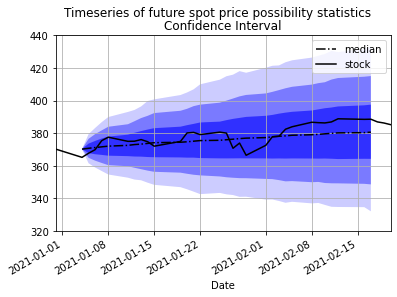

In [3]:
f, a = ProbPlt(sim_stock.S)
stock.history__.Close.plot(ax=a, grid=True, style='-', color='k', label='stock')
a.set_xlim([date(2020, 12, 31), date(2021, 2, 20)])
a.set_ylim([320, 440])
a.legend()
